Exercise: Simple Linear Regression

Problem Statement

You are given a dataset `exam_scores.csv` containing the number of study hours and corresponding exam scores for 50 students. Your task is to build a Simple Linear Regression model to predict the exam score based on the number of study hours.

You should:
- Load and explore the data
- Visualize the data
- Split the data into training and testing sets
- Train a simple linear regression model
- Evaluate the model using R², MAE, MSE, and RMSE
- Visualize the regression line
- Predict the exam score for a student who studied 8 hours


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model, metrics


In [3]:
df=pd.read_csv("C:\\MCA\\DataScience\\DataSets\\exam_scores.csv")
df.head()

,study_hours,exam_score
0,7.66,89.68
1,6.43,83.24
2,1.91,64.71
3,4.98,75.93
4,6.24,84.79


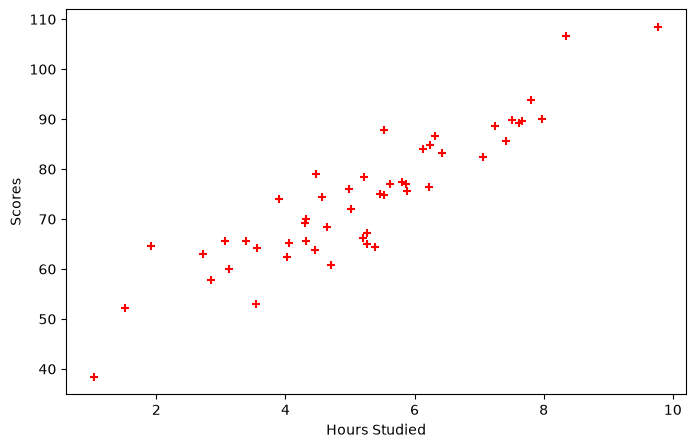

In [4]:
plt.figure(figsize=(8,5))
plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.scatter(df['study_hours'],df['exam_score'],color='red',marker='+',label='Training Data')


In [5]:
X=df[['study_hours']]
y=df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape:",X_train.shape)

Training Data Shape: (40, 1)


In [6]:
model=linear_model.LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.41]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
y_pred=model.predict(X_test)
y_pred

array([86.3826401 , 63.80272661, 69.76844239, 70.40991721, 74.90024091,
       80.41692432, 74.45120854, 94.65766522, 74.90024091, 59.31240291])

In [8]:
r2=model.score(X_test,y_test)
print("R2 Score:",r2)

R2 Score: 0.7129262415977944


In [11]:
mae=metrics.mean_absolute_error(y_test,y_pred)
mse=metrics.mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)

Mean Absolute Error: 7.07465108485755
Mean Squared Error: 61.55258718932295
Root Mean Squared Error: 7.84554569098434


In [10]:
study_hours=10
m=model.coef_[0]
c=model.intercept_
y_predicted=m*study_hours+c
print("Predicted Score:",y_predicted)

Predicted Score: 105.2419996683725
